In [1]:
# =====================================================
# GA4 E-Commerce Business Insights
# Visualizations for Interview Portfolio
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set consistent style
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
# =====================================================
# DATA: Load all results from BigQuery CSV exports
# =====================================================

import os

# Set working directory to notebooks folder
notebook_dir = os.path.dirname(os.path.abspath('__file__'))

# --- Cohort Retention ---
cohort_data = pd.read_csv('cohort_retention.csv')
cohort_data['cohort_month'] = pd.to_datetime(cohort_data['cohort_month']).dt.strftime('%Y-%m')
print("✅ Cohort data loaded:", cohort_data.shape)
print(cohort_data.head())

# --- Category Revenue ---
category_data = pd.read_csv('category_revenue.csv')
print("\n✅ Category data loaded:", category_data.shape)
print(category_data.head())

# --- Weekly Revenue ---
weekly_data = pd.read_csv('weekly_revenue.csv')
weekly_data['week_start'] = pd.to_datetime(weekly_data['week_start'])
print("\n✅ Weekly revenue loaded:", weekly_data.shape)
print(weekly_data.head())

# --- Channel Funnel ---
funnel_data = pd.read_csv('channel_funnel.csv')
print("\n✅ Channel funnel loaded:", funnel_data.shape)
print(funnel_data.head())

# --- RFM Segments ---
rfm_data = pd.read_csv('rfm_segments.csv')
rfm_data['pct_of_customers'] = (
    rfm_data['customer_count'] / rfm_data['customer_count'].sum() * 100
).round(2)
print("\n✅ RFM data loaded:", rfm_data.shape)
print(rfm_data.head())

print("\n🎉 All data loaded successfully!")

✅ Cohort data loaded: (3, 8)
  cohort_month  cohort_size  month_1_retention_pct  month_2_retention_pct  \
0      2020-11         1484                   6.40                   0.67   
1      2020-12         1810                   2.04                   0.00   
2      2021-01          772                   0.00                   0.00   

   month_3_retention_pct  total_cohort_revenue  revenue_per_customer  \
0                    0.0              153652.0                103.54   
1                    0.0              154272.0                 85.23   
2                    0.0               54241.0                 70.26   

   avg_revenue_per_transaction  
0                        72.07  
1                        68.32  
2                        63.66  

✅ Category data loaded: (20, 9)
            category  customers  transactions  total_items_sold  \
0            Apparel       2430          3007              5447   
1                New        907          1050              2132   
2      

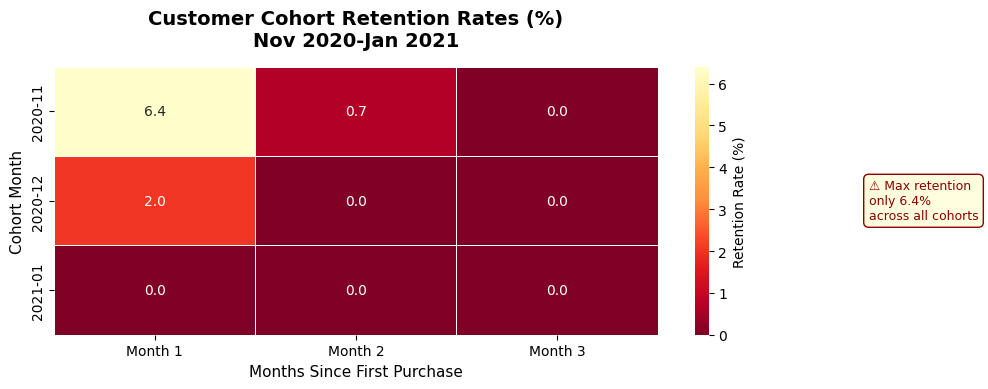

✅ Chart saved: 01_cohort_retention_heatmap.png


In [12]:
# =====================================================
# VISUALIZATION 1: Cohort Retention Heatmap
# =====================================================

fig, ax = plt.subplots(figsize=(10,4))

#prep heatmap data
heatmap_data = cohort_data.set_index('cohort_month')[
    ['month_1_retention_pct', 'month_2_retention_pct','month_3_retention_pct']
].astype(float)

#create heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd_r',linewidths=0.5,linecolor='white', cbar_kws={'label':'Retention Rate (%)'}, ax=ax, vmin=0, vmax=heatmap_data.max().max())

ax.set_title('Customer Cohort Retention Rates (%)\nNov 2020-Jan 2021', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Cohort Month', fontsize=11)
ax.set_xticklabels(['Month 1', 'Month 2', 'Month 3'])

#add context annotation highlighting the retention problem
ax.text(
    1.35, 0.5,
    '⚠️ Max retention\nonly 6.4%\nacross all cohorts',
    transform=ax.transAxes,
    fontsize=9, color='darkred',
    va='center',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='darkred')
)

plt.tight_layout()
plt.savefig('../visualizations/01_cohort_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: 01_cohort_retention_heatmap.png")

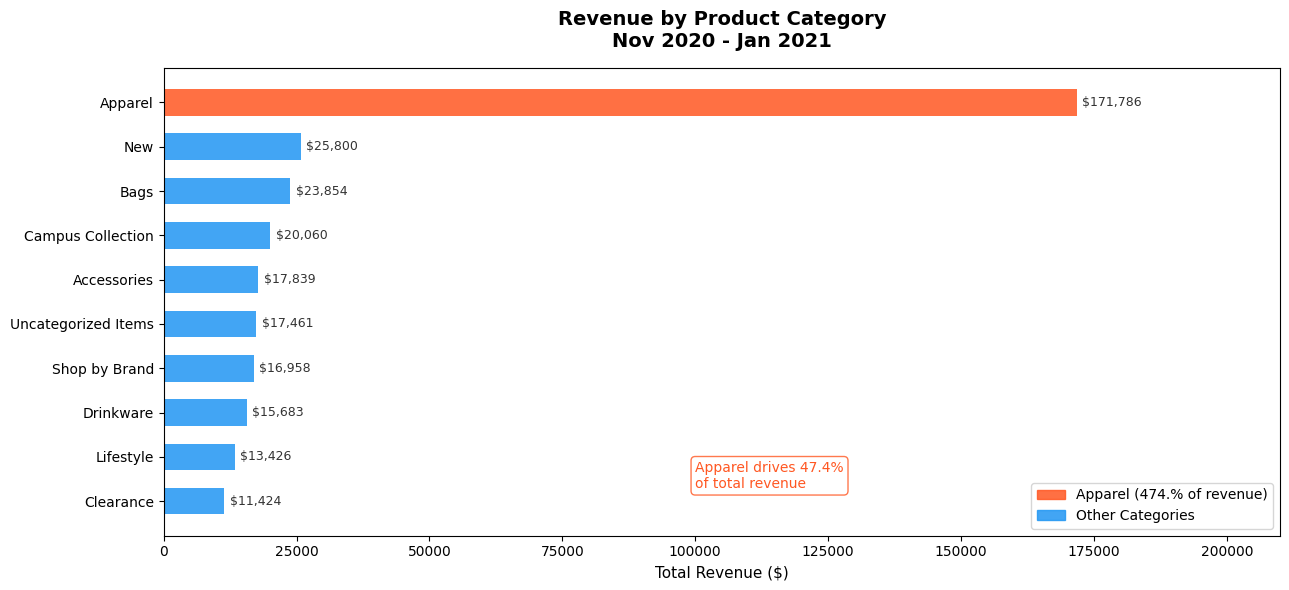

✅ Chart saved: 02_revenue_by_category.png


In [14]:
# =====================================================
# VISUALIZATION 2: Revenue by Category
# =====================================================

fig, ax1 = plt.subplots(figsize=(13,6))

#sort by revenue (take top 10)
category_sorted = category_data.sort_values('total_revenue', ascending=True).tail(10)

colors = ['#FF5722' if cat == 'Apparel' else '#2196F3' for cat in category_sorted['category']]

bars = ax1.barh(category_sorted['category'], category_sorted['total_revenue'], color=colors, alpha=0.85, height=0.6)

#add revenue labels
for bar, rev in zip(bars, category_sorted['total_revenue']):
    ax1.text(bar.get_width()+1000, bar.get_y() + bar.get_height()/2, f'${rev:,.0f}', va='center', fontsize=9, color='#333333')

ax1.set_xlabel('Total Revenue ($)', fontsize=11)
ax1.set_title('Revenue by Product Category\nNov 2020 - Jan 2021', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlim(0, 210000)

#legend
highlight = mpatches.Patch(color='#FF5722', alpha=0.85, label='Apparel (474.% of revenue)')
other = mpatches.Patch(color='#2196F3', alpha=0.85, label='Other Categories')
ax1.legend(handles=[highlight, other], loc='lower right', fontsize=10)

#annotation
ax1.text(100000, 0.3, 'Apparel drives 47.4%\nof total revenue', fontsize=10, color='#FF5722', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#FF5722', alpha=0.8)
)

plt.tight_layout()
plt.savefig('../visualizations/02_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: 02_revenue_by_category.png")

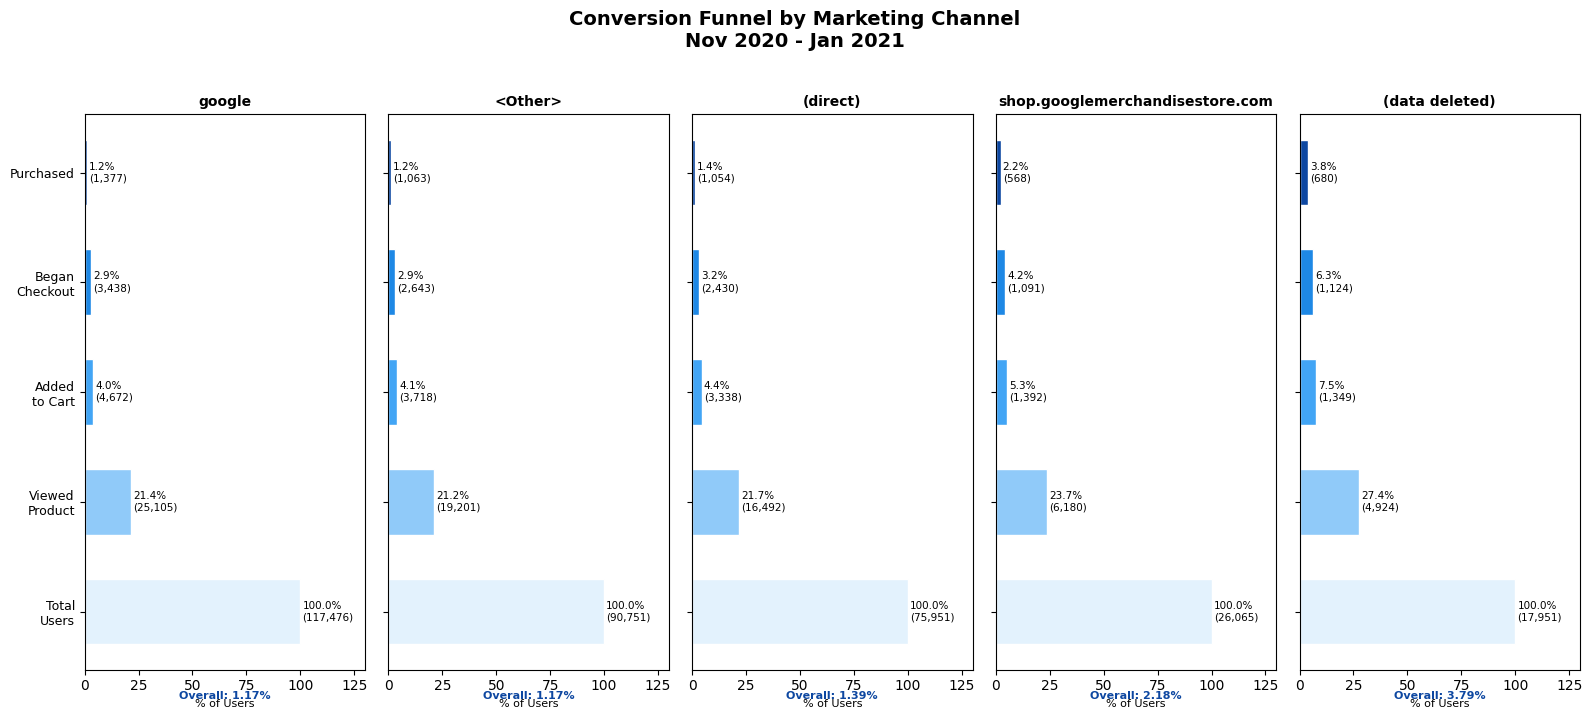

✅ Chart saved: 03_channel_conversion_funnel.png


In [17]:
# =====================================================
# VISUALIZATION 3: Channel Conversion Funnel
# =====================================================

fig, axes = plt.subplots(1, 5, figsize=(16,7), sharey=False)

#take top 5 channels by total users
top_channels = funnel_data.nlargest(5, 'total_users')
channels = top_channels['source'].tolist()

#col names from csv
stages = ['total_users', 'users_viewed_product', 'users_added_to_cart', 
          'users_began_checkout', 'users_purchased']
stage_labels = ['Total\nUsers', 'Viewed\nProduct', 'Added\nto Cart', 
                'Began\nCheckout', 'Purchased']
colors_funnel = ['#E3F2FD', '#90CAF9', '#42A5F5', '#1E88E5', '#0D47A1']

for idx, (ax, channel) in enumerate(zip(axes, channels)):
    row = top_channels[top_channels['source'] == channel].iloc[0]
    values = [row[s] for s in stages]

    pcts = [v / values[0] * 100 for v in values]

    #plot horizontal bars
    for i, (pct, label, color) in enumerate(zip(pcts, stage_labels, colors_funnel)):
        ax.barh(i, pct, color=color, height=0.6, edgecolor='white')
        ax.text(pct + 1, i, f'{pct:.1f}%\n({values[i]:,})', va='center', fontsize=7.5)
    
    ax.set_xlim(0,130)
    ax.set_yticks(range(len(stage_labels)))
    ax.set_yticklabels(stage_labels if idx == 0 else [], fontsize=9)
    ax.set_title(channel, fontsize=10, fontweight='bold')
    ax.set_xlabel('% of Users', fontsize=8)

    #overall conversion annotation
    overall_conv = row['overall_conversion_pct']
    ax.text(65, -0.8, f'Overall: {overall_conv:.2f}%', ha='center', fontsize=8, color='#0D47A1', fontweight='bold')

fig.suptitle('Conversion Funnel by Marketing Channel\nNov 2020 - Jan 2021', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../visualizations/03_channel_conversion_funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: 03_channel_conversion_funnel.png")

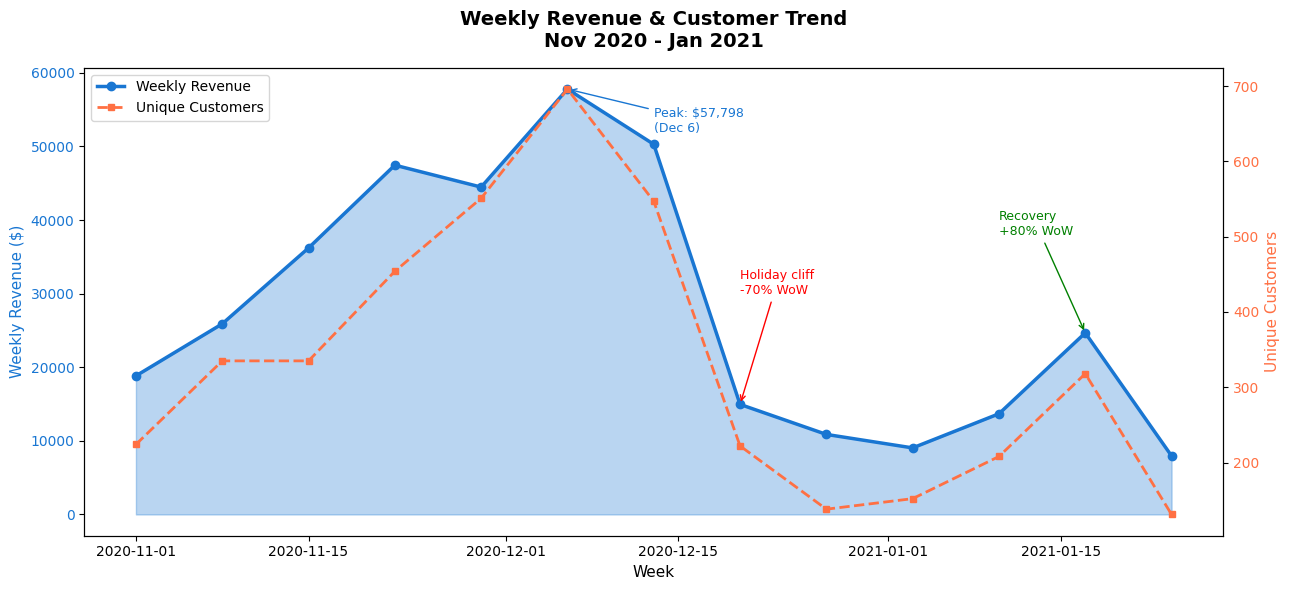

✅ Chart saved: 04_weekly_revenue_trend.png


In [21]:
# =====================================================
# VISUALIZATION 4: Weekly Revenue Trend
# =====================================================

fig, ax1 = plt.subplots(figsize=(13,6))
ax2 = ax1.twinx()

#revenue line (using total_revnue)

ax1.fill_between(weekly_data['week_start'], weekly_data['total_revenue'], alpha=0.3, color='#1976D2')

ax1.plot(weekly_data['week_start'], weekly_data['total_revenue'], color='#1976D2', linewidth=2.5, marker='o', markersize=6, label='Weekly Revenue')

#customers line
ax2.plot(weekly_data['week_start'], weekly_data['unique_customers'], color='#FF7043', linewidth=2, marker='s', markersize=5, linestyle='--', label='Unique Customers')

#annotations
ax1.annotate('Peak: $57,798\n(Dec 6)', xy=(pd.Timestamp('2020-12-06'), 57798), xytext=(pd.Timestamp('2020-12-13'), 52000), fontsize=9, color='#1976D2', arrowprops=dict(arrowstyle='->', color='#1976D2'))

ax1.annotate('Holiday cliff\n-70% WoW', xy=(pd.Timestamp('2020-12-20'), 14954), xytext=(pd.Timestamp('2020-12-20'), 30000), fontsize=9, color='red', arrowprops=dict(arrowstyle='->', color='red'))

ax1.annotate('Recovery\n+80% WoW', xy=(pd.Timestamp('2021-01-17'), 24671), xytext=(pd.Timestamp('2021-01-10'), 38000), fontsize=9, color='green', arrowprops=dict(arrowstyle='->', color='green'))

# Formatting
ax1.set_xlabel('Week', fontsize=11)
ax1.set_ylabel('Weekly Revenue ($)', fontsize=11, color='#1976D2')
ax2.set_ylabel('Unique Customers', fontsize=11, color='#FF7043')
ax1.tick_params(axis='y', labelcolor='#1976D2')
ax2.tick_params(axis='y', labelcolor='#FF7043')
plt.xticks(rotation=45)

ax1.set_title('Weekly Revenue & Customer Trend\nNov 2020 - Jan 2021', fontsize=14, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('../visualizations/04_weekly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: 04_weekly_revenue_trend.png")

In [23]:
# =====================================================
# EXECUTIVE SUMMARY
# =====================================================

summary = """
╔══════════════════════════════════════════════════════════════════════╗
║           GA4 E-COMMERCE BUSINESS INSIGHTS - EXECUTIVE SUMMARY       ║
║                    Analysis Period: Nov 2020 - Jan 2021              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  DATASET OVERVIEW                                                    ║
║  • 4.3M events | 270K users | $362K revenue | 5,692 transactions     ║
║  • Average Order Value: $69.09 | Conversion Rate: 1.64%              ║
║                                                                      ║
║  KEY FINDING 1: CRITICAL RETENTION PROBLEM                           ║
║  • 93.6% of customers never make a second purchase                   ║
║  • Only 6.4% Month-1 retention (Nov cohort)                          ║
║  • Immediate opportunity: post-purchase re-engagement campaign       ║
║                                                                      ║
║  KEY FINDING 2: APPAREL DOMINATES REVENUE                            ║
║  • Apparel = 47.4% of all revenue ($171,786)                         ║
║  • Top cross-sell: Apparel + New Items (508 customers)               ║
║  • VIP customers (7.6% of base) generate 34% of total revenue        ║
║                                                                      ║
║  KEY FINDING 3: GOOGLE DRIVES AWARENESS, REFERRAL CLOSES SALES       ║
║  • Google: $26,503 first-touch vs last-touch gap (awareness channel) ║
║  • Referral: highest revenue per customer at $79-82                  ║
║  • Google CPC underperforming: lowest quality score (0.58)           ║
║                                                                      ║
║  KEY FINDING 4: SEVERE HOLIDAY DEPENDENCY                            ║
║  • Peak week Dec 6: $57,798 revenue                                  ║
║  • Dec 20 crash: -70% WoW revenue drop                               ║
║  • Jan recovery signal: +80% WoW by Jan 17                           ║
║                                                                      ║
║  TOP 3 RECOMMENDATIONS                                               ║
║  1. Launch Month-1 re-engagement email series (93.6% churn rate)     ║
║  2. Reallocate Google CPC budget to referral partnerships            ║
║  3. Create Apparel + New Items bundle for AOV optimization           ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════════╗
║           GA4 E-COMMERCE BUSINESS INSIGHTS - EXECUTIVE SUMMARY       ║
║                    Analysis Period: Nov 2020 - Jan 2021              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  DATASET OVERVIEW                                                    ║
║  • 4.3M events | 270K users | $362K revenue | 5,692 transactions     ║
║  • Average Order Value: $69.09 | Conversion Rate: 1.64%              ║
║                                                                      ║
║  KEY FINDING 1: CRITICAL RETENTION PROBLEM                           ║
║  • 93.6% of customers never make a second purchase                   ║
║  • Only 6.4% Month-1 retention (Nov cohort)                          ║
║  • Immediate opportunity: post-purchase re-engagement campaign       ║
║                                                 